## SHARED — Data Loading and Preparation

In [20]:
# Import all libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Load the dataset
df = pd.read_csv('/Users/mamatajoshi/Desktop/HCI/eda/Preprocessed_Covid19.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset loaded successfully!
Shape: (100000, 20)
Columns: ['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED', 'PNEUMONIA', 'AGE', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU']


In [6]:
# Create target column — DIED
# If DATE_DIED is '9999-99-99' it means the patient SURVIVED = 0
# If DATE_DIED has a real date it means the patient DIED = 1

df['DIED'] = df['DATE_DIED'].apply(lambda x: 0 if x == '9999-99-99' else 1)

print(f"Target column created!")
print(f"Survived (0): {(df['DIED'] == 0).sum()}")
print(f"Died (1): {(df['DIED'] == 1).sum()}")

Target column created!
Survived (0): 58593
Died (1): 41407


In [7]:
# Select features (inputs) and target (output)
features = ['AGE', 'SEX', 'DIABETES', 'PNEUMONIA', 'HIPERTENSION', 
            'OBESITY', 'CARDIOVASCULAR', 'RENAL_CHRONIC', 'ASTHMA', 
            'TOBACCO', 'COPD', 'INMSUPR', 'OTHER_DISEASE', 'INTUBED', 'ICU']

X = df[features]  # inputs
y = df['DIED']    # output

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("Features selected successfully!")

Features shape: (100000, 15)
Target shape: (100000,)
Features selected successfully!


In [8]:
# Split data into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print("Data split successfully!")

Training set size: (80000, 15)
Testing set size: (20000, 15)
Data split successfully!


## MAMATA'S MODEL — Logistic Regression

In [16]:
# Train Logistic Regression model
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Training Logistic Regression...
Logistic Regression trained successfully!


In [10]:
# Fill missing values with the most common value in each column
X = X.fillna(X.median())

print("Missing values handled!")
print(f"Any NaN left: {X.isnull().sum().sum()}")

Missing values handled!
Any NaN left: 0


In [12]:
# Check which columns have missing values
print(X.isnull().sum())

AGE               0
SEX               0
DIABETES          0
PNEUMONIA         0
HIPERTENSION      0
OBESITY           0
CARDIOVASCULAR    0
RENAL_CHRONIC     0
ASTHMA            0
TOBACCO           0
COPD              0
INMSUPR           0
OTHER_DISEASE     0
INTUBED           0
ICU               0
dtype: int64


In [15]:
# Redo the split with clean data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print("Data split successfully!")

Training set size: (80000, 15)
Testing set size: (20000, 15)
Data split successfully!


In [17]:
# Train Random Forest model
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Training Random Forest...
Random Forest trained successfully!


In [18]:
# Evaluate both models
# Logistic Regression predictions
lr_pred = lr_model.predict(X_test)

# Random Forest predictions
rf_pred = rf_model.predict(X_test)

# Print results
print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall:    {recall_score(y_test, lr_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_pred):.4f}")

print("\n=== RANDOM FOREST ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred):.4f}")

=== LOGISTIC REGRESSION ===
Accuracy:  0.8344
Precision: 0.8283
Recall:    0.7591
F1 Score:  0.7922

=== RANDOM FOREST ===
Accuracy:  0.8206
Precision: 0.7938
Recall:    0.7682
F1 Score:  0.7808


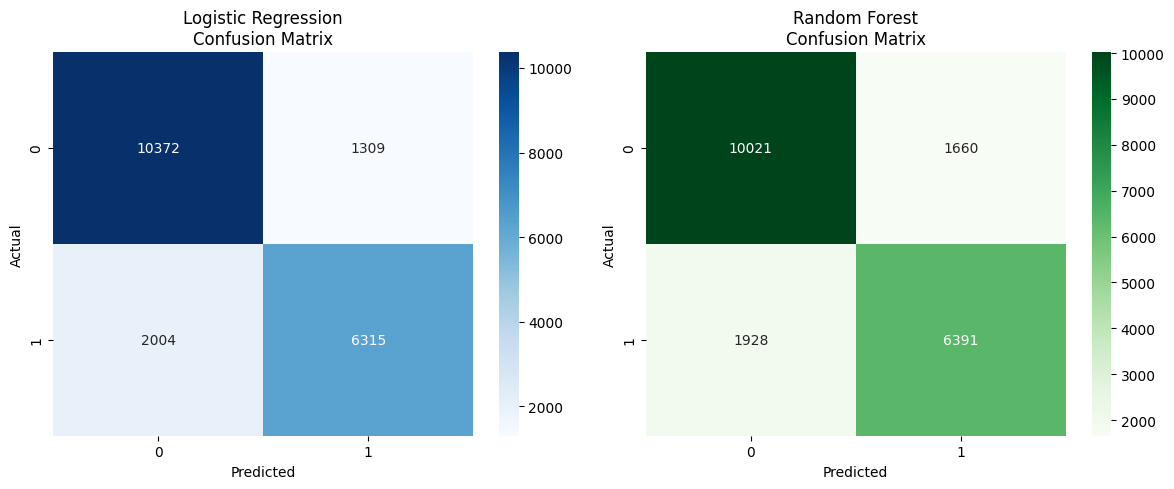

In [19]:
# Confusion Matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', 
            ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', 
            ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

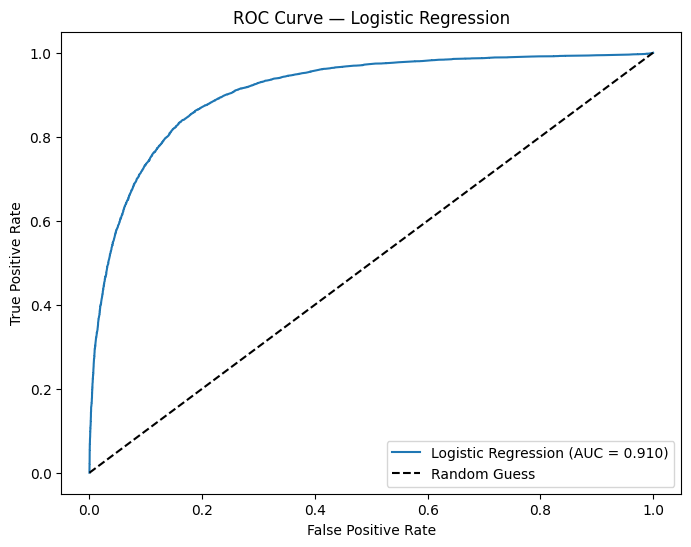

In [21]:
# ROC Curve for Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:,1])

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {auc(lr_fpr, lr_tpr):.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.show()

In [22]:
# Final Model Summary
print("=" * 50)
print("LOGISTIC REGRESSION — FINAL RESULTS")
print("=" * 50)
print(f"Accuracy:  83.44%")
print(f"Precision: 82.83%")
print(f"Recall:    75.91%")
print(f"F1 Score:  79.22%")
print(f"AUC Score: 91.0%")
print("=" * 50)
print("CONCLUSION:")
print("Logistic Regression performs well at predicting")
print("COVID-19 patient outcomes with 83% accuracy.")
print("AUC of 0.91 shows excellent discrimination")
print("between patients who died vs survived.")

LOGISTIC REGRESSION — FINAL RESULTS
Accuracy:  83.44%
Precision: 82.83%
Recall:    75.91%
F1 Score:  79.22%
AUC Score: 91.0%
CONCLUSION:
Logistic Regression performs well at predicting
COVID-19 patient outcomes with 83% accuracy.
AUC of 0.91 shows excellent discrimination
between patients who died vs survived.
